# 06 - Segmentation and Recommendation

Notebook này phân tích hành vi mua sắm ở cấp khách hàng và xây dựng khung recommendation tổng quát, dựa hoàn toàn trên dữ liệu đã làm sạch và các builder hiện có trong project.

**Mục tiêu:**
1. Tạo rule-based segmentation để đọc nhanh chân dung khách hàng.
2. Áp dụng clustering bằng K-Means để phân nhóm tự động theo dữ liệu.
3. Mô tả từng cụm khách hàng theo ngôn ngữ business.
4. Đề xuất cơ chế recommendation gồm cross-sell/up-sell, nhắc chu kỳ mua lặp lại và cá nhân hóa chiến dịch.


## 1. Set Up and Import Existing Project Modules

Notebook này chỉ dùng các tài sản sẵn có của repo:
- `data/cleaned/online_retail_cleaned_full.csv`
- `src.data_contract.run_data_contract_checks`
- `src.features.churn_feature_builder.build_churn_features`
- `src.features.composite_feature_builder.build_composite_features`


In [2]:
import sys
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_contract import run_data_contract_checks
from src.features.churn_feature_builder import build_churn_features
from src.features.composite_feature_builder import build_composite_features

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', font_scale=1.0)

print('Project root:', PROJECT_ROOT)
print('Imports loaded successfully.')

Project root: d:\Data impact\404_Not_Found
Imports loaded successfully.


## 2. Load Cleaned Data and Build Customer-Level Features

Ở bước này, notebook sẽ:
- nạp dữ liệu cleaned transaction-level
- chạy data contract check
- chọn `snapshot_date` giống logic churn labeling trong project
- build churn features và composite features
- bổ sung một số behavioral aggregates từ raw transaction để phục vụ segmentation và recommendation


In [3]:
DATA_PATH = PROJECT_ROOT / 'data' / 'cleaned' / 'online_retail_cleaned_full.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['InvoiceDate'])
contract = run_data_contract_checks(df)

print('Data contract check passed:')
for key, value in contract.items():
    print(f'  {key}: {value}')
print(f'\nRaw shape: {df.shape}')

sales_df = df.loc[df['Quantity'] > 0].copy()
max_date = df['InvoiceDate'].max()
INACTIVITY_DAYS = 60
snapshot_date = max_date - pd.Timedelta(days=INACTIVITY_DAYS)
window_start = snapshot_date - pd.Timedelta(days=89)

churn_features = build_churn_features(
    df,
    snapshot_date=snapshot_date,
    inactivity_days=INACTIVITY_DAYS,
)
composite_features = build_composite_features(churn_features)

sales_history = sales_df.loc[(sales_df['InvoiceDate'] >= window_start) & (sales_df['InvoiceDate'] <= snapshot_date)].copy()

customer_behavior = (
    sales_history.groupby('Customer ID')
    .agg(
        total_units_90d=('Quantity', 'sum'),
        avg_units_per_line_90d=('Quantity', 'mean'),
        distinct_products_90d=('StockCode', 'nunique'),
        distinct_invoices_90d=('Invoice', 'nunique'),
        latest_country=('Country', 'last'),
    )
    .reset_index()
)

invoice_units = (
    sales_history.groupby(['Customer ID', 'Invoice'], as_index=False)
    .agg(invoice_units=('Quantity', 'sum'))
)
invoice_units_summary = (
    invoice_units.groupby('Customer ID', as_index=False)
    .agg(
        avg_units_per_invoice_90d=('invoice_units', 'mean'),
        max_units_per_invoice_90d=('invoice_units', 'max'),
    )
)

customer_df = (
    composite_features
    .merge(customer_behavior, on='Customer ID', how='left')
    .merge(invoice_units_summary, on='Customer ID', how='left')
)

fill_zero_cols = [
    'total_units_90d',
    'avg_units_per_line_90d',
    'distinct_products_90d',
    'distinct_invoices_90d',
    'avg_units_per_invoice_90d',
    'max_units_per_invoice_90d',
]
customer_df[fill_zero_cols] = customer_df[fill_zero_cols].fillna(0)
customer_df['latest_country'] = customer_df['latest_country'].fillna('Unknown')

print(f'Max date:        {max_date}')
print(f'Snapshot date:   {snapshot_date}')
print(f'Window start:    {window_start}')
print(f'Customer table:  {customer_df.shape}')
print(f'Churn rate:      {customer_df["churn_label"].mean():.2%}')

customer_df.head()

Data contract check passed:
  rows: 797885
  columns: 28
  date_min: 2009-12-01 07:45:00
  date_max: 2011-12-09 12:50:00

Raw shape: (797885, 28)


d:\Data impact\404_Not_Found\src\features\churn_feature_builder.py:77: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["avg_order_value_90d"] = (features["monetary_90d"] / safe_frequency).fillna(0.0)
d:\Data impact\404_Not_Found\src\features\churn_feature_builder.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["return_rate_90d"] = (features["return_count_90d"] / safe_frequency).fillna(0.0)


Max date:        2011-12-09 12:50:00
Snapshot date:   2011-10-10 12:50:00
Window start:    2011-07-13 12:50:00
Customer table:  (5581, 26)
Churn rate:      62.78%


d:\Data impact\404_Not_Found\src\features\churn_feature_builder.py:103: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["recency_velocity"] = (features["recency_days"] / safe_tenure).fillna(0.0)


,Customer ID,snapshot_date,recency_days,frequency_90d,monetary_90d,avg_order_value_90d,return_rate_90d,tenure_days,n_unique_days,avg_days_between_orders,day_of_week_mode,recency_velocity,churn_label,purchase_intensity,loyalty_score,retention_score,customer_value_score,churn_risk_index,rfm_segment,total_units_90d,avg_units_per_line_90d,distinct_products_90d,distinct_invoices_90d,latest_country,avg_units_per_invoice_90d,max_units_per_invoice_90d
0,12346,2011-10-10 12:50:00,265,0,0.000,0.000,0.000,665,11,8.543,0,0.398,1,0.000,0.477,0.602,0.158,0.748,Hibernating,0.000,0.000,0.000,0.000,Unknown,0.000,0.000
1,12347,2011-10-10 12:50:00,69,22,584.910,26.587,0.000,343,6,1.669,1,0.201,0,0.064,0.425,0.799,0.165,0.626,Loyal,277.000,12.591,22.000,1.000,Iceland,277.000,277.000
2,12348,2011-10-10 12:50:00,14,3,310.000,103.333,0.000,377,5,7.240,0,0.037,1,0.008,0.461,0.963,0.163,0.598,Loyal,217.000,72.333,3.000,1.000,Finland,217.000,217.000
3,12349,2011-10-10 12:50:00,347,0,0.000,0.000,0.000,675,4,3.075,3,0.514,0,0.000,0.445,0.486,0.158,0.796,Lost,0.000,0.000,0.000,0.000,Unknown,0.000,0.000
4,12350,2011-10-10 12:50:00,249,0,0.000,0.000,0.000,249,1,0.000,2,1.000,1,0.000,0.300,0.000,0.158,0.738,Hibernating,0.000,0.000,0.000,0.000,Unknown,0.000,0.000


## 3. Rule-Based Segmentation

Phần này dùng các feature đang có để tạo một lớp segmentation dễ diễn giải ngay cho business. Logic được thiết kế theo hướng:
- ưu tiên nhận diện nhóm giá trị cao và mua đều
- tách riêng nhóm mua số lượng lớn / mua sỉ
- nhận diện khách một lần hoặc hoạt động rất thấp
- gom nhóm có rủi ro rời bỏ cao để phục vụ reactivation


In [4]:
value_q80 = customer_df['customer_value_score'].quantile(0.80)
loyalty_q75 = customer_df['loyalty_score'].quantile(0.75)
churn_q75 = customer_df['churn_risk_index'].quantile(0.75)
units_invoice_q85 = customer_df['avg_units_per_invoice_90d'].quantile(0.85)
units_total_q90 = customer_df['total_units_90d'].quantile(0.90)
products_q75 = customer_df['distinct_products_90d'].quantile(0.75)

def assign_behavior_segment(row: pd.Series) -> str:
    if (
        row['customer_value_score'] >= value_q80
        and row['loyalty_score'] >= loyalty_q75
        and row['recency_days'] <= 30
    ):
        return 'VIP / Loyal'
    if row['avg_units_per_invoice_90d'] >= units_invoice_q85 or row['total_units_90d'] >= units_total_q90:
        return 'Bulk / Wholesale'
    if row['frequency_90d'] <= 1 and row['n_unique_days'] <= 1:
        return 'One-time / Occasional'
    if row['churn_risk_index'] >= churn_q75 or row['rfm_segment'] in {'At Risk', "Can't Lose Them", 'Lost', 'Hibernating'}:
        return 'At Risk / Churned'
    if row['distinct_products_90d'] >= products_q75 and row['frequency_90d'] >= 2:
        return 'Explorer / Cross-sell Ready'
    return 'Core Active'

customer_df['behavior_segment'] = customer_df.apply(assign_behavior_segment, axis=1)

segment_summary = (
    customer_df.groupby('behavior_segment')
    .agg(
        customers=('Customer ID', 'nunique'),
        recency_days=('recency_days', 'median'),
        frequency_90d=('frequency_90d', 'median'),
        monetary_90d=('monetary_90d', 'median'),
        avg_units_per_invoice_90d=('avg_units_per_invoice_90d', 'median'),
        distinct_products_90d=('distinct_products_90d', 'median'),
        churn_risk_index=('churn_risk_index', 'median'),
        churn_rate=('churn_label', 'mean'),
    )
    .sort_values(['customers', 'monetary_90d'], ascending=[False, False])
)
segment_summary['share_pct'] = (segment_summary['customers'] / segment_summary['customers'].sum() * 100).round(2)

print('Rule-based segment distribution:')
display(segment_summary.reset_index())

Rule-based segment distribution:


,behavior_segment,customers,recency_days,frequency_90d,monetary_90d,avg_units_per_invoice_90d,distinct_products_90d,churn_risk_index,churn_rate,share_pct
0,Core Active,1534,100.000,0.000,0.000,0.000,0.000,0.650,0.589,27.490
1,One-time / Occasional,1302,375.000,0.000,0.000,0.000,0.000,0.812,0.881,23.330
2,At Risk / Churned,1161,347.000,0.000,0.000,0.000,0.000,0.796,0.803,20.800
3,Bulk / Wholesale,597,29.000,32.000,619.500,347.000,30.000,0.597,0.390,10.700
4,Explorer / Cross-sell Ready,498,27.000,30.000,366.650,147.750,28.000,0.599,0.369,8.920
5,VIP / Loyal,489,11.000,58.000,"1,141.090",278.500,48.000,0.584,0.215,8.760


## 4. Data-Driven Segmentation with K-Means

Phân cụm tự động giúp kiểm tra lại segmentation rule-based và tìm những cấu trúc khách hàng mà rule thủ công có thể bỏ sót. Ở đây:
- chuẩn hóa feature trước khi clustering
- thử các giá trị `k` từ 3 đến 6
- chọn `k` theo silhouette score cao nhất


In [6]:
cluster_cols = [
    'recency_days',
    'frequency_90d',
    'monetary_90d',
    'avg_order_value_90d',
    'return_rate_90d',
    'tenure_days',
    'customer_value_score',
    'loyalty_score',
    'churn_risk_index',
    'avg_units_per_invoice_90d',
    'distinct_products_90d',
]

cluster_input = customer_df[['Customer ID'] + cluster_cols].copy()
cluster_model_df = cluster_input.copy().fillna(0.0)

# K-Means is distance-based, so keep non-negative skewed features stable before log transform.
log_cols = [
    'frequency_90d',
    'monetary_90d',
    'avg_order_value_90d',
    'tenure_days',
    'avg_units_per_invoice_90d',
    'distinct_products_90d',
]
for col in log_cols:
    cluster_model_df[col] = np.log1p(cluster_model_df[col].clip(lower=0.0))

X_scaled = StandardScaler().fit_transform(cluster_model_df[cluster_cols])

candidate_scores = []
for k in range(3, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    candidate_scores.append({'k': k, 'silhouette_score': score})

cluster_scores = pd.DataFrame(candidate_scores).sort_values('silhouette_score', ascending=False)
best_k = int(cluster_scores.iloc[0]['k'])

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
customer_df['cluster_id'] = kmeans.fit_predict(X_scaled)

cluster_profile = (
    customer_df.groupby('cluster_id')
    .agg(
        customers=('Customer ID', 'nunique'),
        recency_days=('recency_days', 'median'),
        frequency_90d=('frequency_90d', 'median'),
        monetary_90d=('monetary_90d', 'median'),
        avg_order_value_90d=('avg_order_value_90d', 'median'),
        avg_units_per_invoice_90d=('avg_units_per_invoice_90d', 'median'),
        distinct_products_90d=('distinct_products_90d', 'median'),
        loyalty_score=('loyalty_score', 'median'),
        customer_value_score=('customer_value_score', 'median'),
        churn_risk_index=('churn_risk_index', 'median'),
        churn_rate=('churn_label', 'mean'),
    )
    .sort_values('customer_value_score', ascending=False)
)

cluster_profile['share_pct'] = (cluster_profile['customers'] / cluster_profile['customers'].sum() * 100).round(2)

print('Candidate k by silhouette score:')
display(cluster_scores)
print(f'Selected k = {best_k}')
print('\nCluster profile:')
display(cluster_profile.reset_index())

Candidate k by silhouette score:


,k,silhouette_score
1,4,0.583
0,3,0.566
3,6,0.445
2,5,0.438


Selected k = 4

Cluster profile:


,cluster_id,customers,recency_days,frequency_90d,monetary_90d,avg_order_value_90d,avg_units_per_invoice_90d,distinct_products_90d,loyalty_score,customer_value_score,churn_risk_index,churn_rate,share_pct
0,1,1616,21.000,28.000,501.475,18.038,198.250,26.000,0.550,0.166,0.596,0.353,28.960
1,2,588,19.500,23.000,348.835,16.884,168.000,22.000,0.309,0.164,0.597,0.478,10.540
2,0,3330,322.500,0.000,0.000,0.000,0.000,0.000,0.325,0.158,0.781,0.788,59.670
3,3,47,60.000,2.000,-12.750,-5.685,0.000,0.000,0.528,0.158,0.626,0.596,0.840


## 5. Describe Cluster Personas

Cluster label do K-Means tạo ra chỉ là số. Ở bước này, ta ánh xạ mỗi cluster sang một chân dung business dễ dùng hơn như VIP, Bulk Buyer, Occasional, hay At-Risk.


In [8]:
cluster_profile = cluster_profile.copy()
remaining_clusters = list(cluster_profile.index)
persona_map = {}

vip_cluster = (cluster_profile['customer_value_score'] + cluster_profile['loyalty_score'] - 0.25 * cluster_profile['churn_risk_index']).idxmax()
persona_map[vip_cluster] = 'VIP / High Value'
remaining_clusters.remove(vip_cluster)

if remaining_clusters:
    bulk_cluster = cluster_profile.loc[remaining_clusters, 'avg_units_per_invoice_90d'].idxmax()
    persona_map[bulk_cluster] = 'Bulk Buyer'
    remaining_clusters.remove(bulk_cluster)

if remaining_clusters:
    risk_cluster = (cluster_profile.loc[remaining_clusters, 'churn_risk_index'] + cluster_profile.loc[remaining_clusters, 'churn_rate']).idxmax()
    persona_map[risk_cluster] = 'At Risk / Churned'
    remaining_clusters.remove(risk_cluster)

if remaining_clusters:
    occasional_cluster = (
        cluster_profile.loc[remaining_clusters, 'recency_days']
        - 0.2 * cluster_profile.loc[remaining_clusters, 'frequency_90d']
        - 0.001 * cluster_profile.loc[remaining_clusters, 'monetary_90d']
    ).idxmax()
    persona_map[occasional_cluster] = 'Occasional / One-time'
    remaining_clusters.remove(occasional_cluster)

for cluster_id in remaining_clusters:
    persona_map[cluster_id] = 'Core Mid-value'

cluster_profile['persona'] = cluster_profile.index.map(persona_map)
customer_df = customer_df.drop(columns=['persona'], errors='ignore').merge(
    cluster_profile[['persona']], left_on='cluster_id', right_index=True, how='left'
)

persona_mix = (
    customer_df.groupby(['cluster_id', 'persona', 'behavior_segment'])
    .size()
    .reset_index(name='customers')
    .sort_values(['cluster_id', 'customers'], ascending=[True, False])
)

print('Cluster persona mapping:')
display(cluster_profile.reset_index())
print('\nTop rule-based segment inside each cluster:')
display(persona_mix.groupby(['cluster_id', 'persona']).head(3))

Cluster persona mapping:


,cluster_id,customers,recency_days,frequency_90d,monetary_90d,avg_order_value_90d,avg_units_per_invoice_90d,distinct_products_90d,loyalty_score,customer_value_score,churn_risk_index,churn_rate,share_pct,persona
0,1,1616,21.000,28.000,501.475,18.038,198.250,26.000,0.550,0.166,0.596,0.353,28.960,VIP / High Value
1,2,588,19.500,23.000,348.835,16.884,168.000,22.000,0.309,0.164,0.597,0.478,10.540,Bulk Buyer
2,0,3330,322.500,0.000,0.000,0.000,0.000,0.000,0.325,0.158,0.781,0.788,59.670,At Risk / Churned
3,3,47,60.000,2.000,-12.750,-5.685,0.000,0.000,0.528,0.158,0.626,0.596,0.840,Occasional / One-time



Top rule-based segment inside each cluster:


,cluster_id,persona,behavior_segment,customers
2,0,At Risk / Churned,One-time / Occasional,1295
0,0,At Risk / Churned,At Risk / Churned,1161
1,0,At Risk / Churned,Core Active,874
6,1,VIP / High Value,VIP / Loyal,489
4,1,VIP / High Value,Core Active,415
3,1,VIP / High Value,Bulk / Wholesale,385
7,2,Bulk Buyer,Bulk / Wholesale,212
8,2,Bulk Buyer,Core Active,199
9,2,Bulk Buyer,Explorer / Cross-sell Ready,170
11,3,Occasional / One-time,Core Active,46


## 6. Visualize Segment and Cluster Profiles

Biểu đồ giúp kiểm tra nhanh:
- segment nào đang chiếm tỷ trọng lớn
- cluster nào có giá trị cao nhưng đang tăng rủi ro
- rule-based segmentation có đồng pha với K-Means hay không


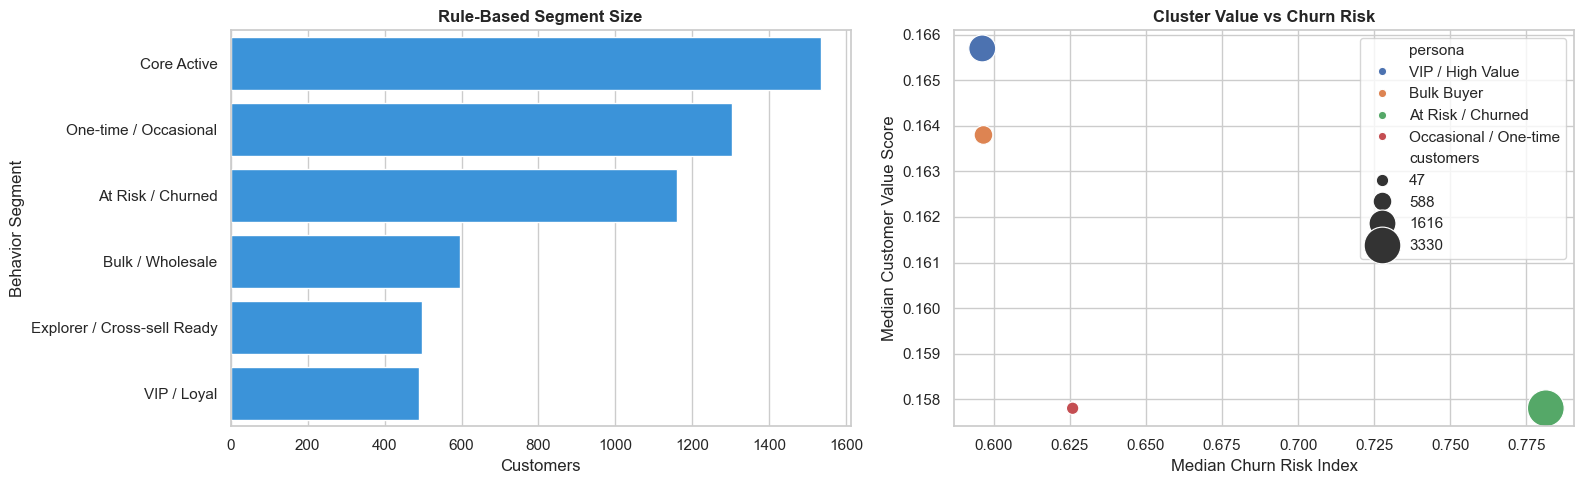

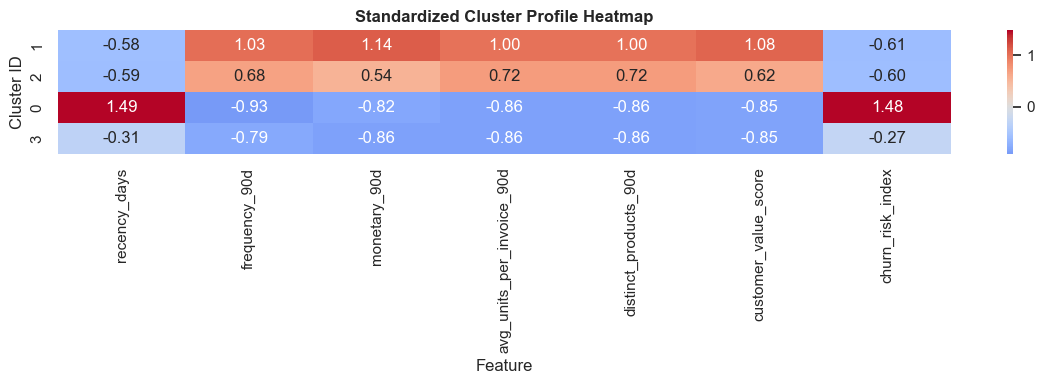

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

segment_plot = segment_summary.sort_values('customers', ascending=False).reset_index()
sns.barplot(data=segment_plot, x='customers', y='behavior_segment', ax=axes[0], color='#2196F3')
axes[0].set_title('Rule-Based Segment Size', fontweight='bold')
axes[0].set_xlabel('Customers')
axes[0].set_ylabel('Behavior Segment')

cluster_plot = cluster_profile.reset_index().sort_values('customer_value_score', ascending=False)
sns.scatterplot(
    data=cluster_plot,
    x='churn_risk_index',
    y='customer_value_score',
    size='customers',
    hue='persona',
    ax=axes[1],
    sizes=(80, 700),
)
axes[1].set_title('Cluster Value vs Churn Risk', fontweight='bold')
axes[1].set_xlabel('Median Churn Risk Index')
axes[1].set_ylabel('Median Customer Value Score')

plt.tight_layout()
plt.show()

cluster_heatmap = cluster_profile[
    ['recency_days', 'frequency_90d', 'monetary_90d', 'avg_units_per_invoice_90d', 'distinct_products_90d', 'customer_value_score', 'churn_risk_index']
].copy()
cluster_heatmap = cluster_heatmap.apply(lambda col: (col - col.mean()) / (col.std() if col.std() else 1), axis=0)

plt.figure(figsize=(12, 4))
sns.heatmap(cluster_heatmap, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Standardized Cluster Profile Heatmap', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

## 7. Recommendation Logic

Recommendation trong notebook này không cố train recommender model riêng. Thay vào đó, ta dựng một framework thực dụng để dùng ngay:
- **Cross-sell / Up-sell** từ product affinity theo invoice
- **Repeat purchase reminder** từ nhịp mua lặp lại của từng khách
- **Campaign personalization** theo behavior segment và cluster persona


In [10]:
recent_sales = sales_df.loc[sales_df['InvoiceDate'] >= max_date - pd.Timedelta(days=180)].copy()
recent_sales['product_label'] = recent_sales['Description'].fillna('Unknown Product').str.strip()
recent_sales = recent_sales.loc[recent_sales['product_label'] != '']

# Limit affinity mining to frequently purchased products and modest basket sizes.
top_products = (
    recent_sales.groupby('product_label')['Invoice']
    .nunique()
    .sort_values(ascending=False)
    .head(200)
    .index
)
recent_sales = recent_sales.loc[recent_sales['product_label'].isin(top_products)].copy()

invoice_products = (
    recent_sales.groupby('Invoice')['product_label']
    .apply(lambda s: sorted(set(s)))
)
invoice_products = invoice_products[invoice_products.apply(lambda items: 2 <= len(items) <= 12)]

pair_counter = Counter()
for items in invoice_products:
    pair_counter.update(combinations(items, 2))

pair_rows = [
    {'product_a': a, 'product_b': b, 'pair_count': count}
    for (a, b), count in pair_counter.items()
]
product_pairs = pd.DataFrame(pair_rows).sort_values('pair_count', ascending=False).reset_index(drop=True)
product_pairs['support_pct'] = (product_pairs['pair_count'] / len(invoice_products) * 100).round(2)

last_purchase = (
    sales_df.sort_values('InvoiceDate')
    .groupby('Customer ID')
    .tail(1)[['Customer ID', 'Description', 'InvoiceDate']]
    .rename(columns={'Description': 'last_product', 'InvoiceDate': 'last_purchase_date'})
)

customer_df = customer_df.merge(last_purchase, on='Customer ID', how='left')
customer_df['last_product'] = customer_df['last_product'].fillna('Unknown Product')

pair_lookup = {}
for row in product_pairs.head(200).itertuples(index=False):
    pair_lookup.setdefault(row.product_a, []).append((row.product_b, row.pair_count))
    pair_lookup.setdefault(row.product_b, []).append((row.product_a, row.pair_count))

for key in pair_lookup:
    pair_lookup[key] = [name for name, _ in sorted(pair_lookup[key], key=lambda x: x[1], reverse=True)[:3]]

order_dates = (
    sales_df.groupby('Customer ID')['InvoiceDate']
    .apply(lambda s: sorted(pd.Series(s.dt.normalize().unique()).tolist()))
)

def median_gap_days(dates: list[pd.Timestamp]) -> float:
    if len(dates) < 2:
        return 0.0
    diffs = np.diff(pd.Series(dates).sort_values().values).astype('timedelta64[D]').astype(int)
    return float(np.median(diffs)) if len(diffs) else 0.0

repeat_cycle = order_dates.apply(median_gap_days).rename('median_reorder_cycle_days').reset_index()
customer_df = customer_df.merge(repeat_cycle, on='Customer ID', how='left')
customer_df['median_reorder_cycle_days'] = customer_df['median_reorder_cycle_days'].fillna(0.0)
customer_df['reorder_due'] = (
    (customer_df['median_reorder_cycle_days'] > 0)
    & (customer_df['recency_days'] >= 0.9 * customer_df['median_reorder_cycle_days'])
)

def recommend_campaign(row: pd.Series) -> str:
    segment = row['behavior_segment']
    persona = row['persona']
    if segment == 'VIP / Loyal' or persona == 'VIP / High Value':
        return 'Premium bundle or loyalty-tier upgrade'
    if segment == 'Bulk / Wholesale' or persona == 'Bulk Buyer':
        return 'Volume discount and pack-size upsell'
    if segment == 'At Risk / Churned' or persona == 'At Risk / Churned':
        return 'Win-back offer with time-limited voucher'
    if segment == 'One-time / Occasional':
        return 'Second-order coupon with bestseller bundle'
    if segment == 'Explorer / Cross-sell Ready':
        return 'Cross-category discovery offer'
    return 'Personalized bestsellers and soft discount'

def recommend_type(row: pd.Series) -> str:
    if row['reorder_due']:
        return 'Repeat-purchase reminder'
    if row['behavior_segment'] in {'Explorer / Cross-sell Ready', 'VIP / Loyal', 'Core Active'}:
        return 'Cross-sell / Up-sell'
    if row['behavior_segment'] in {'At Risk / Churned', 'One-time / Occasional'}:
        return 'Reactivation'
    return 'General personalization'

customer_df['recommendation_type'] = customer_df.apply(recommend_type, axis=1)
customer_df['campaign_action'] = customer_df.apply(recommend_campaign, axis=1)
customer_df['cross_sell_candidates'] = customer_df['last_product'].map(lambda x: ', '.join(pair_lookup.get(x, [])[:3]) if x in pair_lookup else 'No strong pair found')

recommendation_view = customer_df[
    [
        'Customer ID', 'behavior_segment', 'persona', 'rfm_segment', 'recommendation_type',
        'campaign_action', 'last_product', 'cross_sell_candidates', 'median_reorder_cycle_days',
        'recency_days', 'customer_value_score', 'churn_risk_index'
    ]
].sort_values(['recommendation_type', 'customer_value_score'], ascending=[True, False])

print('Top product affinity pairs:')
display(product_pairs.head(15))
print('\nRecommendation sample:')
display(recommendation_view.head(20))

Top product affinity pairs:


,product_a,product_b,pair_count,support_pct
0,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,180,2.950
1,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT VINTAGE CHRISTMAS,162,2.660
2,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,156,2.560
3,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,151,2.480
4,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,147,2.410
5,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,139,2.280
6,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,135,2.220
7,PARTY BUNTING,SPOTTY BUNTING,133,2.180
8,LARGE WHITE HEART OF WICKER,SMALL WHITE HEART OF WICKER,126,2.070
9,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,122,2.000



Recommendation sample:


,Customer ID,behavior_segment,persona,rfm_segment,recommendation_type,campaign_action,last_product,cross_sell_candidates,median_reorder_cycle_days,recency_days,customer_value_score,churn_risk_index
2409,14911,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,SET OF 6 HERB TINS SKETCHBOOK,No strong pair found,2.000,0,0.653,0.141
5407,18102,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,HOME SWEET HOME BLACKBOARD,No strong pair found,7.500,5,0.612,0.390
2161,14646,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,JUMBO BAG 50'S CHRISTMAS,No strong pair found,6.000,4,0.586,0.352
5166,17841,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,RED STRIPE CERAMIC DRAWER KNOB,No strong pair found,4.000,3,0.513,0.171
1698,14156,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,SET 8 CANDLES VINTAGE DOILY,No strong pair found,4.000,0,0.499,0.385
67,12415,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,RABBIT NIGHT LIGHT,"POSTAGE, RED TOADSTOOL LED NIGHT LIGHT",20.500,5,0.435,0.442
4863,17511,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,BISCUIT TIN 50'S CHRISTMAS,No strong pair found,14.000,3,0.334,0.486
3452,16029,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,JUMBO BAG STRAWBERRY,"JUMBO BAG RED RETROSPOT, JUMBO BAG PINK POLKADOT",8.000,0,0.330,0.514
4078,16684,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,SET OF 60 PANTRY DESIGN CAKE CASES,No strong pair found,14.500,5,0.318,0.523
540,12931,VIP / Loyal,VIP / High Value,Champions,Cross-sell / Up-sell,Premium bundle or loyalty-tier upgrade,ALPHABET STENCIL CRAFT,No strong pair found,11.500,6,0.297,0.534


## 8. Final Business Reading

Kết hợp rule-based segmentation, K-Means clustering và recommendation framework để trả lời ba câu hỏi cuối:
1. Khách hàng của chúng ta đang được chia thành những nhóm nào?
2. Nhóm nào cần giữ chân, nhóm nào phù hợp để tăng basket size hoặc cross-sell?
3. Cơ chế recommendation nào nên ưu tiên theo hành vi thực tế?


In [11]:
final_summary = (
    customer_df.groupby(['behavior_segment', 'persona'])
    .agg(
        customers=('Customer ID', 'nunique'),
        median_monetary_90d=('monetary_90d', 'median'),
        median_frequency_90d=('frequency_90d', 'median'),
        median_recency_days=('recency_days', 'median'),
        avg_churn_risk=('churn_risk_index', 'mean'),
        reorder_due_rate=('reorder_due', 'mean'),
    )
    .reset_index()
    .sort_values(['customers', 'median_monetary_90d'], ascending=[False, False])
)

playbook = pd.DataFrame([
    {'scenario': 'VIP / Loyal', 'recommended_focus': 'Upsell premium bundles, loyalty rewards, early-access products'},
    {'scenario': 'Bulk / Wholesale', 'recommended_focus': 'Volume pricing, carton/bundle offers, replenishment reminders'},
    {'scenario': 'Explorer / Cross-sell Ready', 'recommended_focus': 'Cross-category suggestions based on affinity pairs'},
    {'scenario': 'One-time / Occasional', 'recommended_focus': 'Second-purchase incentive and bestseller starter bundle'},
    {'scenario': 'At Risk / Churned', 'recommended_focus': 'Win-back campaign, urgency coupon, reminders near reorder cycle'},
    {'scenario': 'Core Active', 'recommended_focus': 'Personalized nudges, soft discount, category expansion'},
])

print('Business summary by segment/persona:')
display(final_summary.head(20))
print('\nRecommendation playbook:')
display(playbook)

Business summary by segment/persona:


,behavior_segment,persona,customers,median_monetary_90d,median_frequency_90d,median_recency_days,avg_churn_risk,reorder_due_rate
10,One-time / Occasional,At Risk / Churned,1295,0.000,0.000,376.000,0.829,0.076
0,At Risk / Churned,At Risk / Churned,1161,0.000,0.000,347.000,0.795,0.840
3,Core Active,At Risk / Churned,874,0.000,0.000,142.000,0.698,0.755
12,VIP / Loyal,VIP / High Value,489,"1,141.090",58.000,11.000,0.576,0.076
6,Core Active,VIP / High Value,415,208.020,10.000,32.000,0.611,0.224
2,Bulk / Wholesale,VIP / High Value,385,612.280,30.000,35.000,0.601,0.294
9,Explorer / Cross-sell Ready,VIP / High Value,327,366.110,30.000,32.000,0.603,0.291
1,Bulk / Wholesale,Bulk Buyer,212,628.055,34.000,17.000,0.595,0.160
4,Core Active,Bulk Buyer,199,194.370,9.000,26.000,0.608,0.181
7,Explorer / Cross-sell Ready,Bulk Buyer,170,372.855,32.000,17.000,0.597,0.165



Recommendation playbook:


,scenario,recommended_focus
0,VIP / Loyal,"Upsell premium bundles, loyalty rewards, early..."
1,Bulk / Wholesale,"Volume pricing, carton/bundle offers, replenis..."
2,Explorer / Cross-sell Ready,Cross-category suggestions based on affinity p...
3,One-time / Occasional,Second-purchase incentive and bestseller start...
4,At Risk / Churned,"Win-back campaign, urgency coupon, reminders n..."
5,Core Active,"Personalized nudges, soft discount, category e..."
